# Klasyfikacja symboli nutowych - wieloskalowe dopasowanie szablonu

## Dlaczego nie GeneralizedHoughGuil do klasyfikacji?

`GeneralizedHoughGuil` jest detektorem obiektow w **duzej scenie**: szuka wzorca wewnatrz
wiekszego obrazu, glosujac w przestrzeni (x, y, skala, kat). Gdy obraz zapytania ma **podobny
rozmiar co wzorzec** (izolowany symbol), akumulator nie dziala sensownie - algorytm nagradza
male skale, bo malutki template pasuje do wielu fragmentow obrazu.

## Wlasciwe podejscie: wieloskalowe `matchTemplate`

Dla kazdego wzorca i kazdej testowanej skali:
1. Przeskaluj zapytanie do rozmiaru wzorca x skala
2. Oblicz `cv2.matchTemplate(..., TM_CCOEFF_NORMED)` - wynik w [-1, 1]
3. Wez maksimum po wszystkich skalach i pozycjach

To jest **dokladnie** to co GHT mial robic, ale dzialajace poprawnie dla malych obrazow.

| Wlasciwosc | GHT (Guil) | Multi-scale matchTemplate |
|---|---|---|
| Skala | tak (zakres) | tak (siatka krokow) |
| Izolowane symbole | NIE akumulator nie dziala | TAK dziala |
| Interpretacja wyniku | glosy / edge_px | TM_CCOEFF_NORMED w [-1, 1] |
| Szybkosc | wolny (4D akumulator) | szybki |

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass, field
import time

PATTERNS_DIR = Path('../classical_recognition/patterns_padded')

# Siatka skal do przeszukania
SCALE_RANGE = np.concatenate([
    np.arange(0.4, 1.0, 0.05),
    np.arange(1.0, 2.6, 0.1),
])

print('cv2:', cv2.__version__)
print(f'Siatka skal: {len(SCALE_RANGE)} krokow, {SCALE_RANGE[0]:.2f}-{SCALE_RANGE[-1]:.2f}')
print('Katalog wzorow:', PATTERNS_DIR.resolve())

cv2: 4.13.0
Siatka skal: 28 krokow, 0.40-2.50
Katalog wzorow: D:\Pulpit\Studia\Semestr 6\GGSN\Projektowe\OMR-classic-vs-deep-comparison\classical_recognition\patterns_padded


## Ladowanie wzorow

In [29]:
@dataclass
class PatternTemplate:
    name: str
    template: np.ndarray    # uint8, biale na czarnym


def _to_white_on_black(gray: np.ndarray) -> np.ndarray:
    corners = [gray[0,0], gray[0,-1], gray[-1,0], gray[-1,-1]]
    bg = int(np.median(corners))
    return cv2.bitwise_not(gray) if bg > 127 else gray.copy()


def load_templates(patterns_dir: Path) -> list[PatternTemplate]:
    EXCLUDE = {'augmentation.png'}
    templates = []
    for path in sorted(patterns_dir.glob('*.png')):
        if path.name in EXCLUDE:
            continue
        gray = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if gray is None:
            print(f'  [WARN] nie mozna wczytac {path.name}')
            continue
        templates.append(PatternTemplate(
            name     = path.stem,
            template = _to_white_on_black(gray),
        ))
    print(f'Zaladowano {len(templates)} wzorow.')
    return templates


TEMPLATES = load_templates(PATTERNS_DIR)

Zaladowano 42 wzorow.


## Glowna funkcja klasyfikacji `classify_symbol()`

In [30]:
from dataclasses import dataclass as _dc

@_dc
class ClassifyResult:
    label:       str
    score:       float    # TM_CCOEFF_NORMED w [-1, 1]; im wyzszy tym lepszy
    best_scale:  float    # skala przy ktorej znaleziono najlepsze dopasowanie
    ranking:     list     # lista (label, score, scale) top_k najlepszych


def _match_score(query_gray: np.ndarray,
                 template: np.ndarray,
                 scales: np.ndarray) -> tuple[float, float]:
    h_t, w_t = template.shape
    best_score, best_scale = -1.0, 1.0

    for s in scales:
        qh = max(1, int(query_gray.shape[0] * s))
        qw = max(1, int(query_gray.shape[1] * s))
        q_resized = cv2.resize(query_gray, (qw, qh), interpolation=cv2.INTER_LINEAR)

        if qh >= h_t and qw >= w_t:
            img, tmpl = q_resized, template
        elif qh > 0 and qw > 0:
            tmpl = cv2.resize(template, (qw, qh), interpolation=cv2.INTER_LINEAR)
            img  = q_resized
        else:
            continue

        res   = cv2.matchTemplate(img, tmpl, cv2.TM_CCOEFF_NORMED)
        score = float(res.max())
        if score > best_score:
            best_score, best_scale = score, s

    return best_score, best_scale


def classify_symbol(
    img_white_on_black: np.ndarray,
    templates: list[PatternTemplate] = TEMPLATES,
    scales: np.ndarray = SCALE_RANGE,
    top_k: int = 5,
    verbose: bool = False,
) -> ClassifyResult:
    """
    Klasyfikuje symbol nutowy metoda wieloskalowego matchTemplate.

    Parametry
    ----------
    img_white_on_black : np.ndarray
        Obraz wejsciowy (uint8, szarosc lub BGR).
        Konwencja: biale symbole na czarnym tle.
        Rozmiar moze byc dowolny - algorytm przeszukuje siatke skal.
    templates : list[PatternTemplate]
        Lista wzorow (domyslnie globalna TEMPLATES).
    scales : np.ndarray
        Siatka mnoznikow skali do przeszukania.
    top_k : int
        Ile najlepszych wynikow zwrocic w rankingu.
    verbose : bool
        Drukuje wyniki dla kazdego wzorca.

    Zwraca
    -------
    ClassifyResult z:
        - label      - nazwa klasy
        - score      - TM_CCOEFF_NORMED w [-1, 1]
        - best_scale - skala przy ktorej znaleziono dopasowanie
        - ranking    - lista (label, score, scale) top_k najlepszych
    """
    if img_white_on_black.ndim == 3:
        query = cv2.cvtColor(img_white_on_black, cv2.COLOR_BGR2GRAY)
    else:
        query = img_white_on_black.copy()

    results = []
    t0 = time.perf_counter()

    for pt in templates:
        score, scale = _match_score(query, pt.template, scales)
        results.append((pt.name, score, scale))
        if verbose:
            print(f'  {pt.name:<20s}  score={score:6.3f}  scale={scale:.2f}')

    elapsed = time.perf_counter() - t0
    if verbose:
        print(f'Czas: {elapsed*1000:.1f} ms')

    results.sort(key=lambda r: r[1], reverse=True)
    ranking = [(name, score, scale) for name, score, scale in results[:top_k]]
    best = results[0]

    return ClassifyResult(
        label      = best[0],
        score      = best[1],
        best_scale = best[2],
        ranking    = ranking,
    )

print('classify_symbol() gotowa.')

classify_symbol() gotowa.


## Test na wzorcach (self-test)

Kazdy wzorzec testujemy na sobie - oczekujemy score bliskiego 1.0 i skali ~1.0.

In [31]:
pattern_map = {pt.name: pt for pt in TEMPLATES}

print(f'{"Wzorzec":<22s}  {"Top-1":<22s}  {"score":>6s}  {"skala":>6s}  OK?')
print('-' * 68)

correct = 0
for pt in TEMPLATES:
    result = classify_symbol(pt.template)
    ok = result.label == pt.name
    correct += int(ok)
    mark = 'OK' if ok else f'FAIL -> {result.label}'
    print(f'{pt.name:<22s}  {result.label:<22s}  {result.score:6.3f}  {result.best_scale:6.2f}  {mark}')

print(f'\nSelf-test: {correct}/{len(TEMPLATES)} poprawnych')

Wzorzec                 Top-1                    score   skala  OK?
--------------------------------------------------------------------
12_8                    12_8                     1.000    0.40  OK
2_2                     2_2                      1.000    0.40  OK
3_2                     3_2                      1.000    0.40  OK
3_4                     3_4                      1.000    0.40  OK
3_8                     3_8                      1.000    0.40  OK
4_4                     4_4                      1.000    0.40  OK
5_4                     5_4                      1.000    0.45  OK
5_8                     5_8                      1.000    0.40  OK
6_4                     6_4                      1.000    0.45  OK
6_8                     6_8                      1.000    0.40  OK
7_8                     7_8                      1.000    0.40  OK
9_8                     9_8                      1.000    0.40  OK
barline                 barline                  1.000    0

## Test odpornosci na zmiane skali

Skalujemy wzorzec (0.5x, 0.75x, 1.5x, 2.0x) i sprawdzamy, czy klasyfikacja pozostaje prawidlowa.

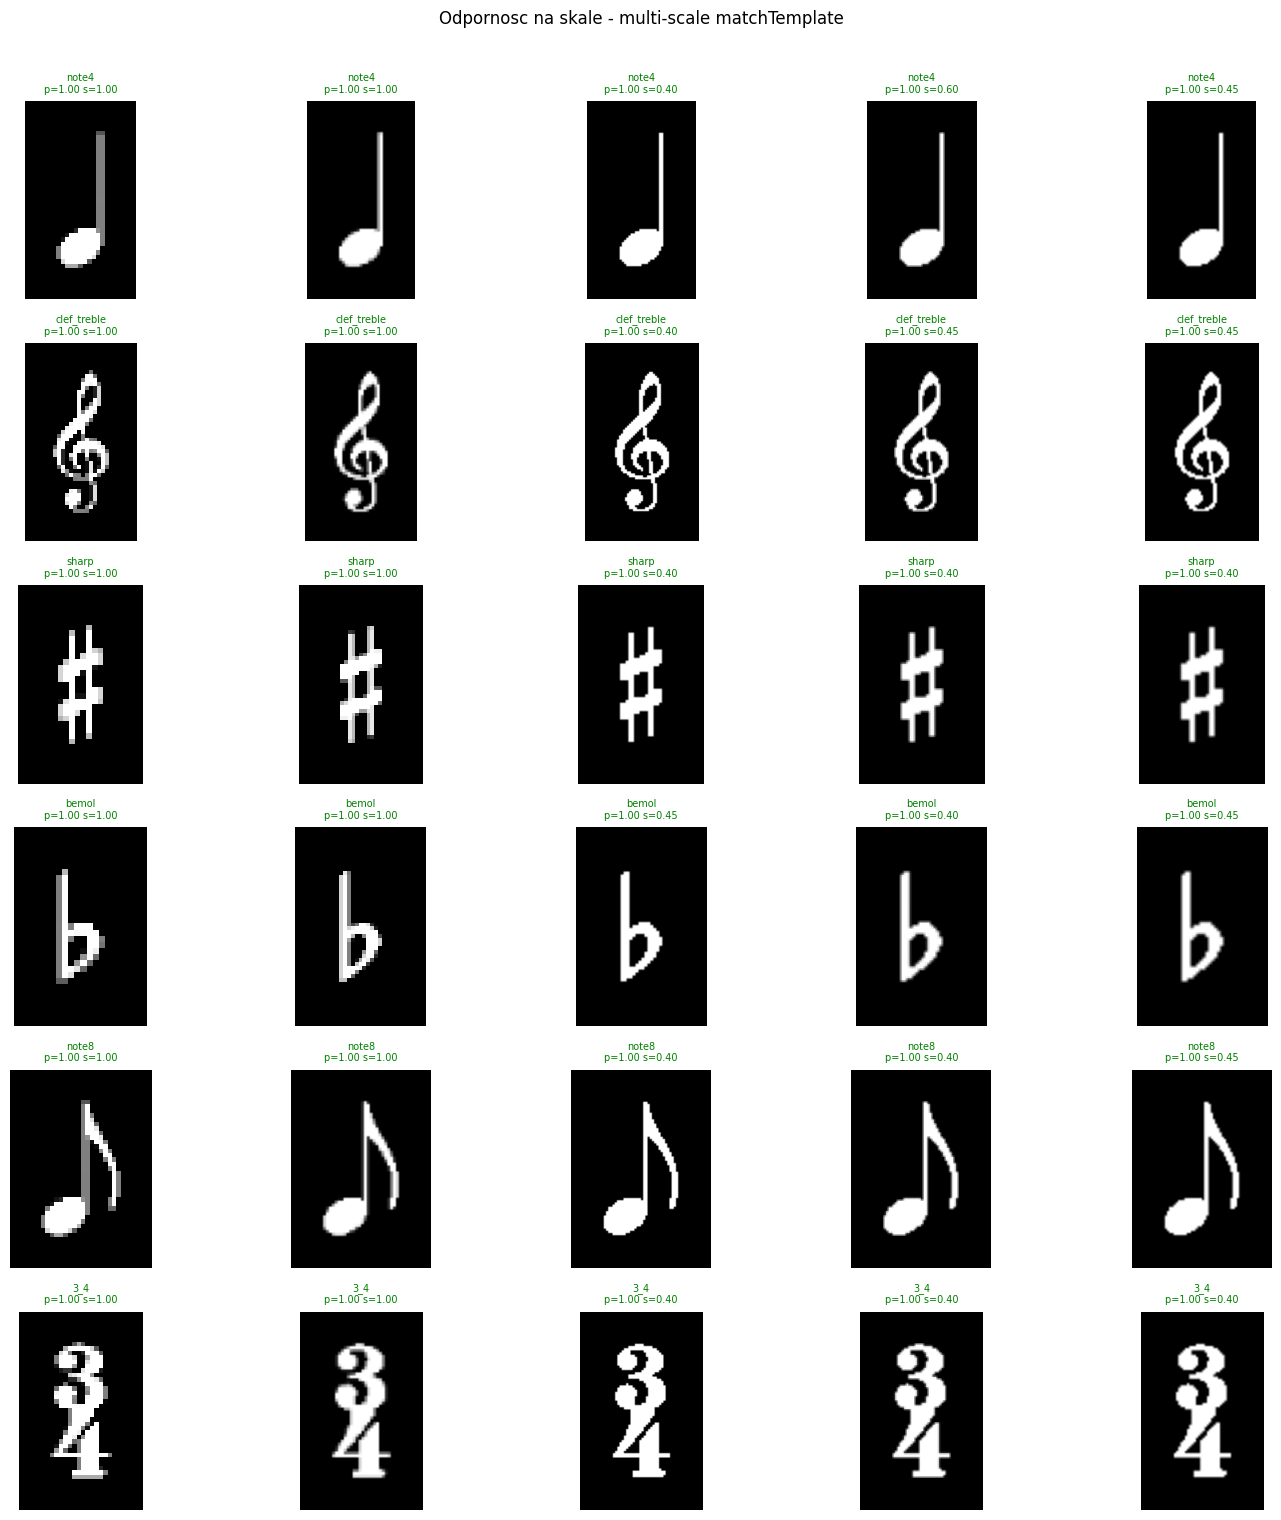

In [32]:
TEST_PATTERNS = ['note4', 'clef_treble', 'sharp', 'bemol', 'note8', '3_4']
SCALES_TEST   = [0.5, 0.75, 1.0, 1.5, 2.0]

fig, axes = plt.subplots(len(TEST_PATTERNS), len(SCALES_TEST),
                          figsize=(len(SCALES_TEST)*3, len(TEST_PATTERNS)*2.5))

for row, pname in enumerate(TEST_PATTERNS):
    if pname not in pattern_map:
        print(f'[WARN] wzorzec {pname!r} nie istnieje'); continue
    tpl = pattern_map[pname].template

    for col, s in enumerate(SCALES_TEST):
        ax = axes[row, col]
        h, w = tpl.shape
        scaled = cv2.resize(tpl, (max(1,int(w*s)), max(1,int(h*s))), interpolation=cv2.INTER_LINEAR)

        result = classify_symbol(scaled)
        ok     = result.label == pname
        color  = 'green' if ok else 'red'

        ax.imshow(scaled, cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'{result.label}\np={result.score:.2f} s={result.best_scale:.2f}',
                     fontsize=7, color=color)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(pname, fontsize=8, rotation=0, labelpad=55, va='center')

plt.suptitle('Odpornosc na skale - multi-scale matchTemplate', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Test na obrazach z `data/note_pitches_selected`

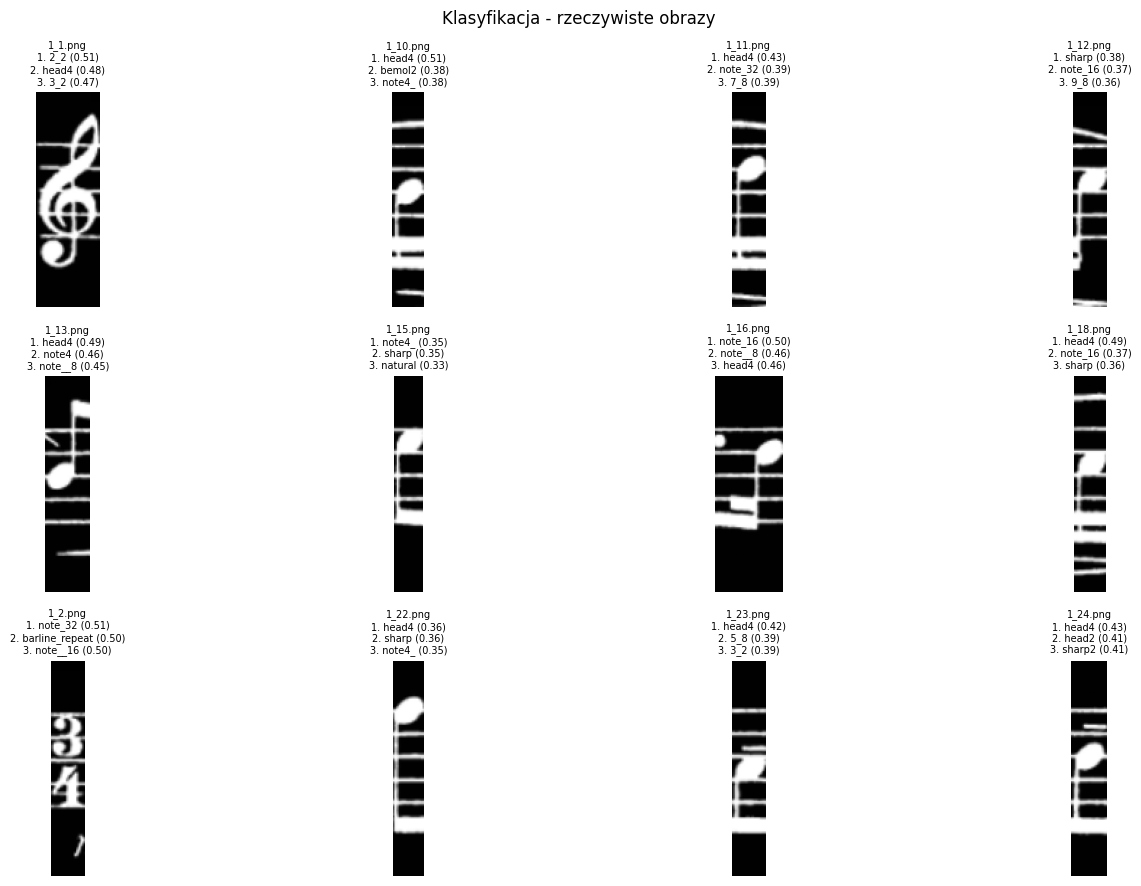

In [33]:
DATA_DIR   = Path('../data/note_pitches_selected')
SAMPLE_N   = 12

sample_paths = sorted(DATA_DIR.glob('*.png'))[:SAMPLE_N]
cols = 4
rows = (len(sample_paths) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))
axes = axes.flatten()

for ax, path in zip(axes, sample_paths):
    gray = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if gray is None: ax.axis('off'); continue
    query = _to_white_on_black(gray)
    result = classify_symbol(query)
    ax.imshow(query, cmap='gray', vmin=0, vmax=255)
    ranking_str = '\n'.join(
        f'{i+1}. {lbl} ({s:.2f})' for i,(lbl,s,_) in enumerate(result.ranking[:3])
    )
    ax.set_title(f'{path.name}\n{ranking_str}', fontsize=7)
    ax.axis('off')

for ax in axes[len(sample_paths):]:
    ax.axis('off')
plt.suptitle('Klasyfikacja - rzeczywiste obrazy', fontsize=12)
plt.tight_layout()
plt.show()

## Wizualizacja rankingu dla pojedynczego obrazu

  12_8                  score= 0.329  scale=1.90
  2_2                   score= 0.507  scale=2.30
  3_2                   score= 0.468  scale=2.40
  3_4                   score= 0.459  scale=2.50
  3_8                   score= 0.439  scale=2.40
  4_4                   score= 0.435  scale=2.50
  5_4                   score= 0.461  scale=2.50
  5_8                   score= 0.457  scale=2.40
  6_4                   score= 0.444  scale=2.50
  6_8                   score= 0.448  scale=2.40
  7_8                   score= 0.408  scale=2.30
  9_8                   score= 0.429  scale=2.50
  barline               score= 0.427  scale=2.50
  barline_double        score= 0.305  scale=0.40
  barline_end           score= 0.395  scale=2.20
  barline_repeat        score= 0.451  scale=2.50
  bemol                 score= 0.379  scale=1.80
  bemol2                score= 0.413  scale=2.40
  clef_alt              score= 0.240  scale=2.50
  clef_bass             score= 0.341  scale=2.30
  clef_treble       

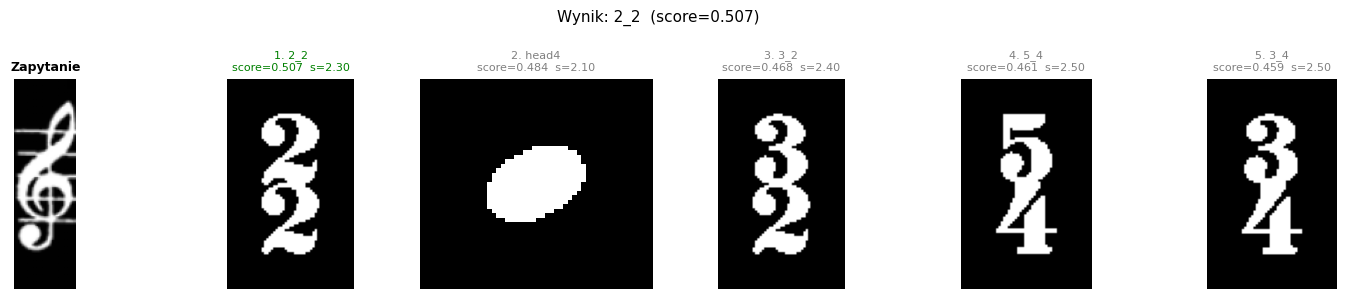

In [34]:
def show_classification(img_white_on_black: np.ndarray, top_k: int = 5):
    result = classify_symbol(img_white_on_black, top_k=top_k, verbose=True)

    fig, axes = plt.subplots(1, top_k + 1, figsize=((top_k+1)*2.5, 3))
    axes[0].imshow(img_white_on_black, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title('Zapytanie', fontsize=9, fontweight='bold')
    axes[0].axis('off')

    for i, (lbl, score, scale) in enumerate(result.ranking):
        ax = axes[i+1]
        if lbl in pattern_map:
            ax.imshow(pattern_map[lbl].template, cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'{i+1}. {lbl}\nscore={score:.3f}  s={scale:.2f}',
                     fontsize=8, color='green' if i == 0 else 'gray')
        ax.axis('off')

    plt.suptitle(f'Wynik: {result.label}  (score={result.score:.3f})', fontsize=11)
    plt.tight_layout()
    plt.show()


first_img_path = sorted(DATA_DIR.glob('*.png'))[0]
first_img = _to_white_on_black(cv2.imread(str(first_img_path), cv2.IMREAD_GRAYSCALE))
show_classification(first_img)

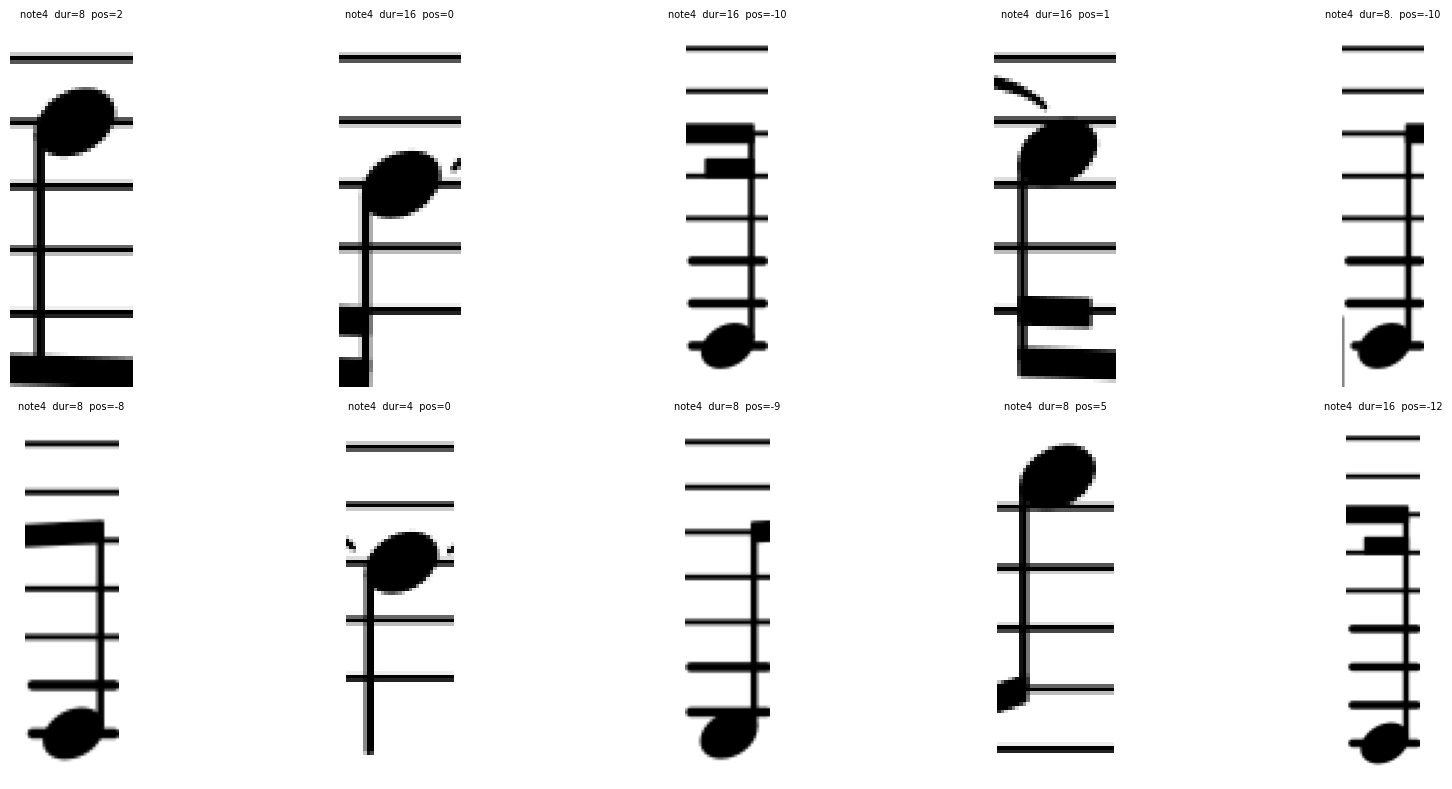

<Figure size 640x480 with 0 Axes>

In [43]:
import json
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import defaultdict

BASE_DIR = Path('../data/archive/ds2_dense')
IMG_DIR  = BASE_DIR / 'images'

ann      = json.load(open(BASE_DIR / 'deepscores_train.json'))
id2img   = {i['id']: i for i in ann['images']}
id2cat   = ann['categories']

# ── Grupuj anotacje per obraz ─────────────────────────────────────────────────
by_img = defaultdict(list)
for aid, a in ann['annotations'].items():
    by_img[a['img_id']].append(a)

NOTEHEADS = {'noteheadBlackOnLine', 'noteheadBlackInSpace',
             'noteheadHalfOnLine',  'noteheadHalfInSpace'}
FLAGS     = {'flag8thUp', 'flag8thDown'}


def x_overlap(b1, b2, tolerance=5):
    """Czy dwa bbox-y [x1,y1,x2,y2] nakładają się poziomo."""
    return b1[0] - tolerance <= b2[2] and b2[0] - tolerance <= b1[2]


def merge_bboxes(bboxes):
    """Połącz listę [x1,y1,x2,y2] w jeden obejmujący bbox."""
    x1 = min(b[0] for b in bboxes)
    y1 = min(b[1] for b in bboxes)
    x2 = max(b[2] for b in bboxes)
    y2 = max(b[3] for b in bboxes)
    return x1, y1, x2, y2


def is_stem_for_notehead(nh_bbox, stem_bbox, max_gap=8):
    """Stem musi nakładać się poziomo I być pionowo przyległy do główki."""
    # Poziomo
    if not x_overlap(nh_bbox, stem_bbox, tolerance=3):
        return False
    # Pionowo: stem musi dotykać lub lekko zachodzić na główkę
    nh_y1, nh_y2 = nh_bbox[1], nh_bbox[3]
    st_y1, st_y2 = stem_bbox[1], stem_bbox[3]
    return st_y1 <= nh_y2 + max_gap and st_y2 >= nh_y1 - max_gap


def is_flag_for_stem(stem_bbox, flag_bbox, tolerance=5):
    """Flaga musi nakładać się poziomo ze stemem i być przy jego końcu."""
    if not x_overlap(stem_bbox, flag_bbox, tolerance=tolerance):
        return False
    # Flaga przy górnym lub dolnym końcu stema
    st_y1, st_y2 = stem_bbox[1], stem_bbox[3]
    fl_y1, fl_y2 = flag_bbox[1], flag_bbox[3]
    near_top    = fl_y1 <= st_y1 + (st_y2 - st_y1) * 0.4
    near_bottom = fl_y2 >= st_y2 - (st_y2 - st_y1) * 0.4
    return near_top or near_bottom


def find_staff_for_note(note_bbox, staffs):
    """
    Znajdź pięciolinię której y-zakres obejmuje centrum nuty.
    Jeśli żadna nie obejmuje dokładnie — weź najbliższą.
    """
    note_cy = (note_bbox[1] + note_bbox[3]) / 2

    # Najpierw szukaj staff który zawiera centrum nuty pionowo
    for s in staffs:
        if s[1] <= note_cy <= s[3]:
            return s

    # Fallback: najbliższy staff po odległości centrum
    return min(staffs, key=lambda s: abs((s[1]+s[3])/2 - note_cy))


def build_note_crops(img_id, max_crops=50):
    anns = by_img[img_id]
    img_info = id2img[int(img_id)]
    img = cv2.imread(str(IMG_DIR / img_info['filename']), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return []

    noteheads, stems, flags, staffs = [], [], [], []
    for a in anns:
        name = id2cat[a['cat_id'][0]]['name']
        bbox = [int(v) for v in a['a_bbox']]
        if name in NOTEHEADS:       noteheads.append((bbox, name, a.get('comments','')))
        elif name == 'stem':        stems.append(bbox)
        elif name in FLAGS:         flags.append(bbox)
        elif name == 'staff':       staffs.append(bbox)

    crops = []
    for nh_bbox, nh_name, comments in noteheads:

        matching_stems = [s for s in stems if is_stem_for_notehead(nh_bbox, s)]
        if len(matching_stems) > 1:
            nh_cx = (nh_bbox[0] + nh_bbox[2]) / 2
            nh_cy = (nh_bbox[1] + nh_bbox[3]) / 2
            matching_stems = [min(matching_stems,
                key=lambda s: abs((s[0]+s[2])/2 - nh_cx) + abs((s[1]+s[3])/2 - nh_cy))]

        matching_flags = []
        for s in matching_stems:
            matching_flags += [f for f in flags if is_flag_for_stem(s, f)]

        # ── Wyznacz granice poziome z nuty ────────────────────────────────────
        all_bboxes = [nh_bbox] + matching_stems + matching_flags
        x1, _, x2, _ = merge_bboxes(all_bboxes)

        # ── Granice pionowe z pięciolinii ──────────────────────────────────────
        if staffs:
            staff = find_staff_for_note(nh_bbox, staffs)
            # Rozszerz żeby zmieścić i staff i nutę ze stemem
            y1 = min(staff[1], nh_bbox[1], *(s[1] for s in matching_stems))
            y2 = max(staff[3], nh_bbox[3], *(s[3] for s in matching_stems))
        else:
            _, y1, _, y2 = merge_bboxes(all_bboxes)

        # Padding: wąski poziomo (tylko nuta), szerszy pionowo (nuty ledgerowe)
        pad_x, pad_y = 6, 8
        x1 = max(0, x1 - pad_x)
        x2 = min(img.shape[1], x2 + pad_x)
        y1 = max(0, y1 - pad_y)
        y2 = min(img.shape[0], y2 + pad_y)

        crop = img[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        # Etykieta z comments
        fields = dict(f.split(':') for f in comments.split(';') if ':' in f)
        duration     = fields.get('duration', '?').strip()
        rel_position = fields.get('rel_position', '?').strip()

        is_open = 'Half' in nh_name or 'Whole' in nh_name
        if not matching_stems:
            note_type = 'note1'
        elif matching_flags:
            note_type = 'note8'
        elif is_open:
            note_type = 'note2'
        else:
            note_type = 'note4'

        label = f'{note_type}  dur={duration}  pos={rel_position}'
        crops.append((crop, label))
        if len(crops) >= max_crops:
            break

    return crops


# ── Wyświetl przykłady ────────────────────────────────────────────────────────
all_crops = []
for img_id in list(by_img.keys())[:10]:      # przeszukaj kilka obrazów
    all_crops.extend(build_note_crops(img_id, max_crops=20))
    if len(all_crops) >= 20:
        break

# Pokaż po kilka z każdego typu
from collections import defaultdict as dd
by_label = dd(list)
for crop, lbl in all_crops:
    by_label[lbl].append(crop)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for ax, (crop, label) in zip(axes.flatten(), all_crops[:10]):
    ax.imshow(crop, cmap='gray')
    ax.set_title(label, fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()

plt.suptitle('DeepScores: złożone nuty (notehead + stem + flag)', fontsize=12)
plt.tight_layout()
plt.show()

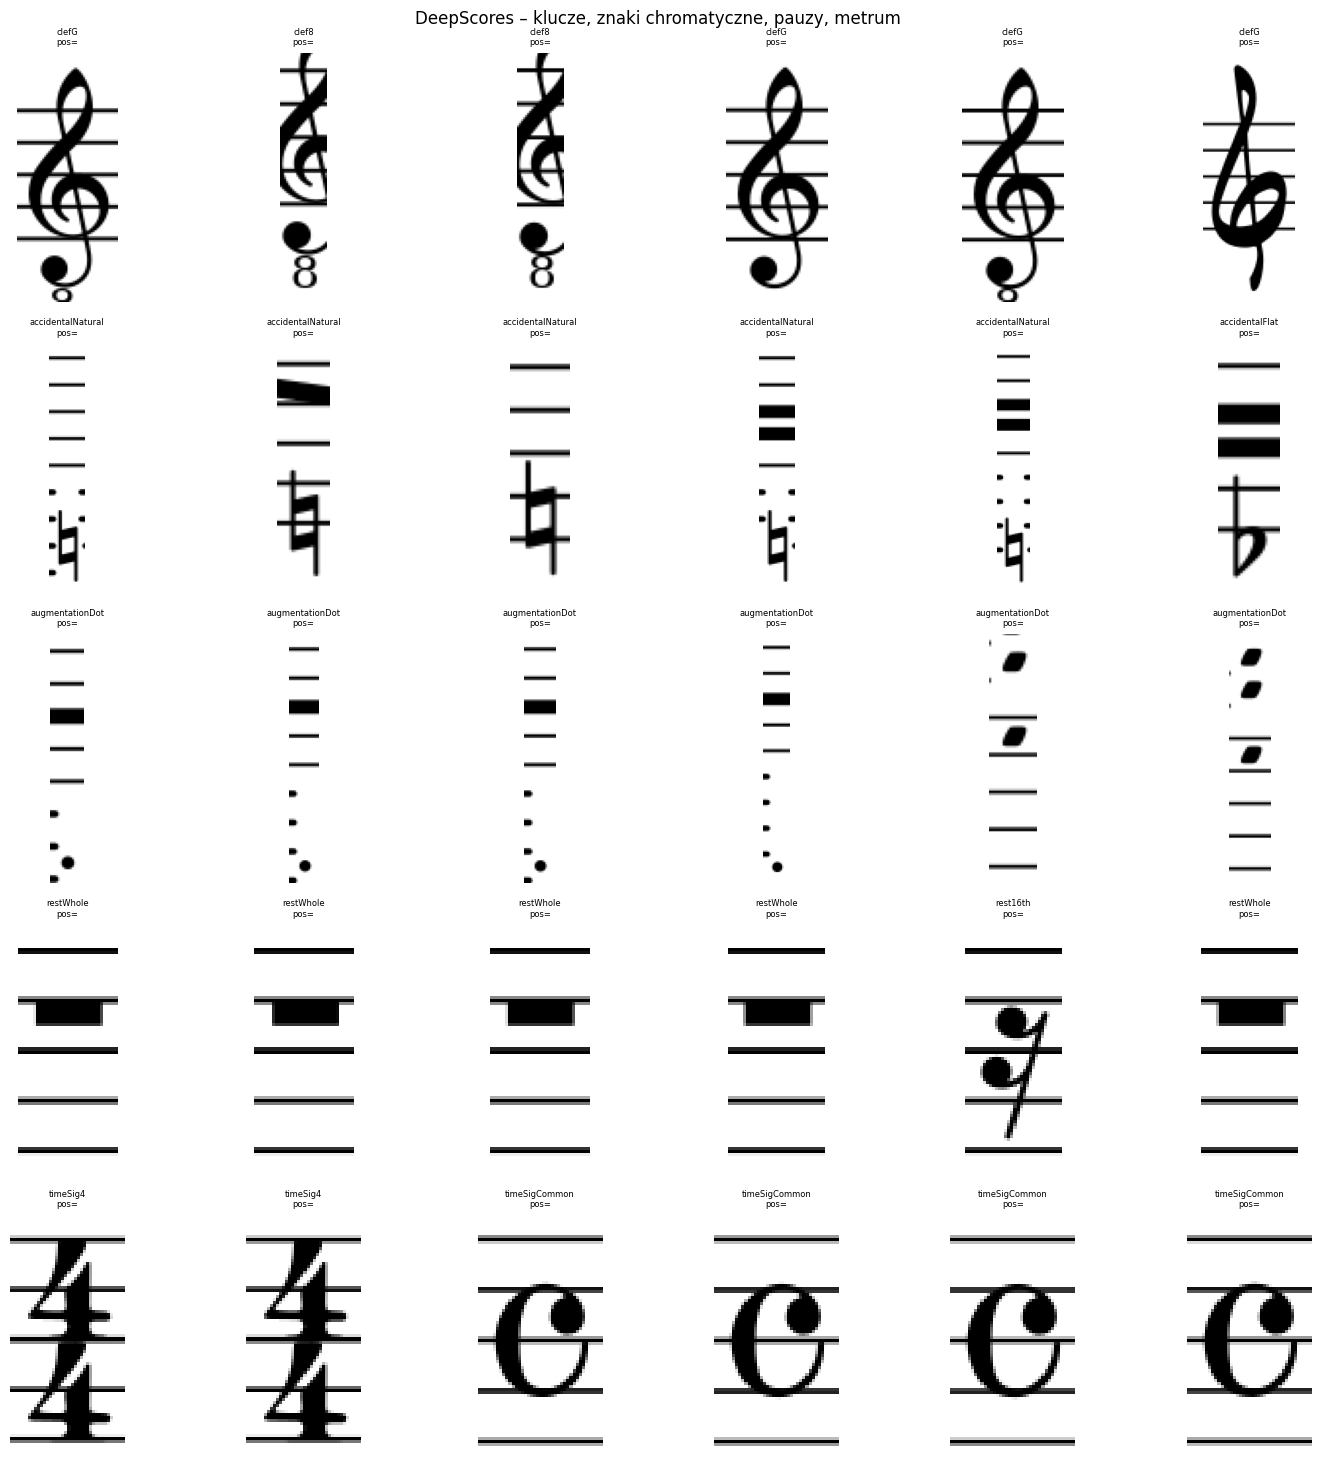

In [44]:
import json
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import defaultdict

BASE_DIR = Path('../data/archive/ds2_dense')
IMG_DIR  = BASE_DIR / 'images'

# Wczytaj JSON (masz już załadowany - jeśli nie, odkomentuj)
# ann = json.load(open(BASE_DIR / 'deepscores_train.json'))  # tylko jeśli masz RAM
# Zakładam że masz już: id2img, id2cat, by_img z poprzednich komórek

# ── Definicja grup symboli ────────────────────────────────────────────────────
SYMBOL_GROUPS = {
    'clef': {
        'clefG', 'clefF', 'clefCAlto', 'clefCTenor', 'clef8',
    },
    'accidental': {
        'accidentalSharp', 'accidentalFlat', 'accidentalNatural',
        'accidentalDoubleSharp', 'accidentalDoubleFlat',
    },
    'augmentation': {
        'augmentationDot',
    },
    'rest': {
        'restWhole', 'restHalf', 'restQuarter', 'rest8th', 'rest16th', 'rest32nd',
    },
    'timesig': {
        'timeSig0','timeSig1','timeSig2','timeSig3','timeSig4',
        'timeSig5','timeSig6','timeSig7','timeSig8','timeSig9',
        'timeSigCommon', 'timeSigCutCommon',
    },
}

ALL_TARGETS = {name: group for group, names in SYMBOL_GROUPS.items() for name in names}

PAD_X, PAD_Y = 6, 8


def find_staff_for_bbox(bbox, staffs):
    cy = (bbox[1] + bbox[3]) / 2
    for s in staffs:
        if s[1] <= cy <= s[3]:
            return s
    return min(staffs, key=lambda s: abs((s[1]+s[3])/2 - cy))


def extract_symbol_crops(img_id, max_per_image=30):
    """Wytnij pojedyncze symbole z kontekstem pięciolinii."""
    anns   = by_img[img_id]
    img_info = id2img[int(img_id)]
    img = cv2.imread(str(IMG_DIR / img_info['filename']), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return []

    staffs  = []
    targets = []   # (bbox, cat_name, comments)

    for a in anns:
        name = id2cat[a['cat_id'][0]]['name']
        bbox = [int(v) for v in a['a_bbox']]
        if name == 'staff':
            staffs.append(bbox)
        elif name in ALL_TARGETS:
            targets.append((bbox, name, a.get('comments', '')))

    crops = []
    for bbox, name, comments in targets[:max_per_image]:
        x1, y1_sym, x2, y2_sym = bbox

        # Granice pionowe: staff + symbol (dla kluczy wystających poza staff)
        if staffs:
            staff = find_staff_for_bbox(bbox, staffs)
            y1 = min(staff[1], y1_sym)
            y2 = max(staff[3], y2_sym)
        else:
            y1, y2 = y1_sym, y2_sym

        # Padding i clip
        x1 = max(0, x1 - PAD_X);  x2 = min(img.shape[1], x2 + PAD_X)
        y1 = max(0, y1 - PAD_Y);  y2 = min(img.shape[0], y2 + PAD_Y)

        crop = img[y1:y2, x1:x2]
        if crop.size == 0 or crop.shape[0] < 5 or crop.shape[1] < 5:
            continue

        fields = dict(t.split(':') for t in comments.split(';') if ':' in t)
        group  = ALL_TARGETS[name]

        crops.append({
            'crop':     crop,
            'cat_name': name,
            'group':    group,
            'rel_pos':  fields.get('rel_position', ''),
        })

    return crops


# ── Zbierz przykłady per grupa ────────────────────────────────────────────────
collected = defaultdict(list)
SAMPLES_PER_GROUP = 6

for img_id in list(by_img.keys()):
    if all(len(v) >= SAMPLES_PER_GROUP for v in collected.values()
           if len(SYMBOL_GROUPS) > 0):
        # Sprawdź czy wszystkie grupy mają dość próbek
        if all(len(collected[g]) >= SAMPLES_PER_GROUP for g in SYMBOL_GROUPS):
            break

    for item in extract_symbol_crops(img_id):
        g = item['group']
        if len(collected[g]) < SAMPLES_PER_GROUP * 3:
            collected[g].append(item)


# ── Wyświetl siatkę: wiersze = grupy, kolumny = przykłady ────────────────────
n_cols = SAMPLES_PER_GROUP
n_rows = len(SYMBOL_GROUPS)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2.5, n_rows*3))

for row, group in enumerate(SYMBOL_GROUPS):
    items = collected[group][:n_cols]
    for col in range(n_cols):
        ax = axes[row, col]
        if col < len(items):
            ax.imshow(items[col]['crop'], cmap='gray')
            ax.set_title(f"{items[col]['cat_name']}\npos={items[col]['rel_pos']}",
                         fontsize=6)
        else:
            ax.set_facecolor('#eee')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(group, fontsize=9, rotation=0, labelpad=60, va='center',
                          fontweight='bold')

plt.suptitle('DeepScores – klucze, znaki chromatyczne, pauzy, metrum', fontsize=12)
plt.tight_layout()
plt.show()

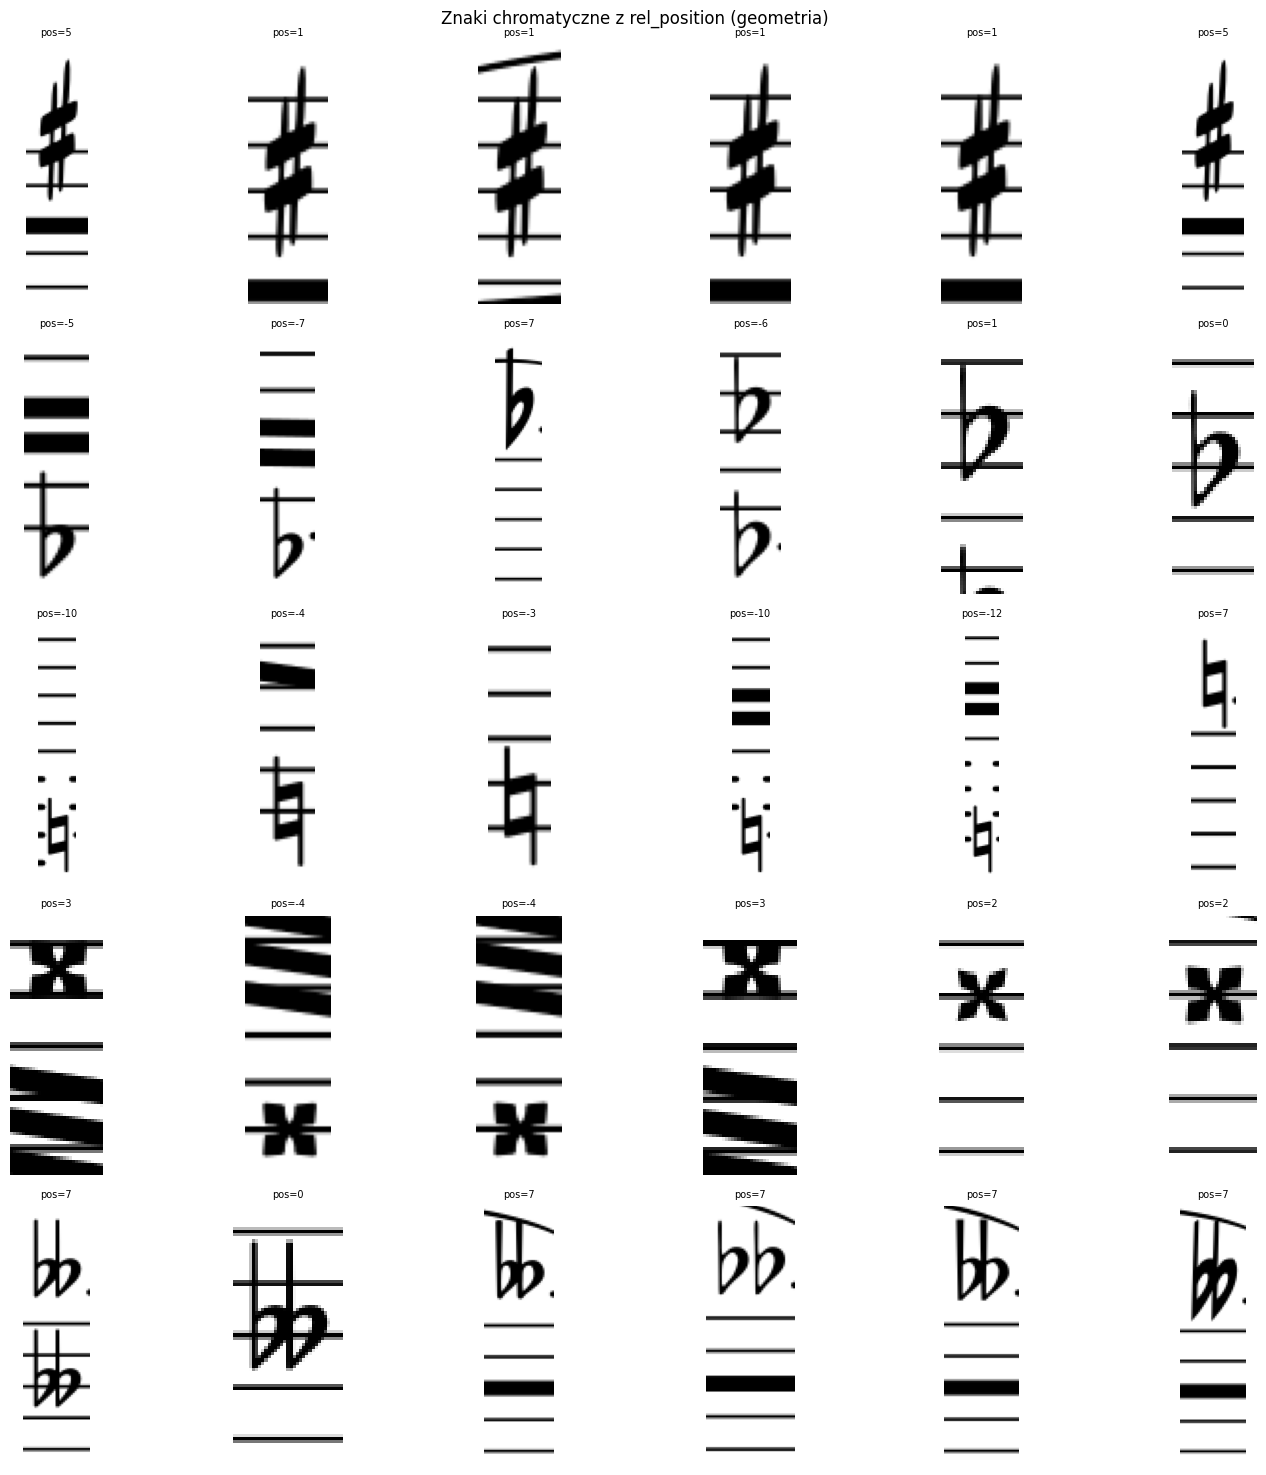

In [45]:
ACCIDENTALS = {
    'accidentalSharp':       'sharp',
    'accidentalFlat':        'flat',
    'accidentalNatural':     'natural',
    'accidentalDoubleSharp': 'double_sharp',
    'accidentalDoubleFlat':  'double_flat',
}
NOTEHEADS = {
    'noteheadBlackOnLine', 'noteheadBlackInSpace',
    'noteheadHalfOnLine',  'noteheadHalfInSpace',
    'noteheadWholeOnLine', 'noteheadWholeInSpace',
}


def find_notehead_for_accidental(acc_bbox, noteheads_in_image, max_gap_x=40, max_gap_y=20):
    """
    Znajdź nutę modyfikowaną przez znak chromatyczny.
    Nuta leży bezpośrednio NA PRAWO i na tej samej wysokości co znak.

    acc_bbox         : [x1, y1, x2, y2] znaku chromatycznego
    noteheads_in_image: lista (bbox, name, comments)
    """
    acc_cx = (acc_bbox[0] + acc_bbox[2]) / 2
    acc_cy = (acc_bbox[1] + acc_bbox[3]) / 2

    candidates = []
    for nh_bbox, nh_name, nh_comments in noteheads_in_image:
        nh_cx = (nh_bbox[0] + nh_bbox[2]) / 2
        nh_cy = (nh_bbox[1] + nh_bbox[3]) / 2

        dx = nh_bbox[0] - acc_bbox[2]   # odległość: prawa krawędź znaku → lewa krawędź nuty
        dy = abs(nh_cy - acc_cy)         # różnica pionowa centrum

        # Nuta musi być z prawej (dx >= -5) i niezbyt daleko (dx <= max_gap_x)
        # oraz na tej samej wysokości (dy <= max_gap_y)
        if -5 <= dx <= max_gap_x and dy <= max_gap_y:
            candidates.append((dx + dy * 0.5, nh_bbox, nh_comments))  # heurystyka odległości

    if not candidates:
        return None, None

    # Weź najbliższego kandydata
    candidates.sort(key=lambda c: c[0])
    _, best_bbox, best_comments = candidates[0]
    fields = dict(t.split(':') for t in best_comments.split(';') if ':' in t)
    return best_bbox, fields.get('rel_position', '')


def extract_accidental_crops(img_id, max_crops=40):
    anns     = by_img[img_id]
    img_info = id2img[int(img_id)]
    img = cv2.imread(str(IMG_DIR / img_info['filename']), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return []

    accidentals, noteheads, staffs = [], [], []
    for a in anns:
        name = id2cat[a['cat_id'][0]]['name']
        bbox = [int(v) for v in a['a_bbox']]
        if name in ACCIDENTALS:
            accidentals.append((bbox, name, a.get('comments', '')))
        elif name in NOTEHEADS:
            noteheads.append((bbox, name, a.get('comments', '')))
        elif name == 'staff':
            staffs.append(bbox)

    crops = []
    for acc_bbox, acc_name, _ in accidentals[:max_crops]:

        # Znajdź nutę do której należy znak
        nh_bbox, rel_position = find_notehead_for_accidental(acc_bbox, noteheads)

        # Jeśli nie znaleziono nuty — oblicz rel_position z geometrii pięciolinii
        if rel_position == '' and staffs:
            staff = find_staff_for_bbox(acc_bbox, staffs)
            staff_cy  = (staff[1] + staff[3]) / 2
            staff_h   = (staff[3] - staff[1]) or 1
            space     = staff_h / 8          # odległość między liniami ≈ staff_h/8
            acc_cy    = (acc_bbox[1] + acc_bbox[3]) / 2
            rel_position = str(round((staff_cy - acc_cy) / (space / 2)))

        # Granice pionowe: staff + znak (znaki mogą wystawać poza pięciolinię)
        x1, y1_sym, x2, y2_sym = acc_bbox
        if staffs:
            staff = find_staff_for_bbox(acc_bbox, staffs)
            y1 = min(staff[1], y1_sym)
            y2 = max(staff[3], y2_sym)
        else:
            y1, y2 = y1_sym, y2_sym

        x1 = max(0, x1 - PAD_X);  x2 = min(img.shape[1], x2 + PAD_X)
        y1 = max(0, y1 - PAD_Y);  y2 = min(img.shape[0], y2 + PAD_Y)

        crop = img[y1:y2, x1:x2]
        if crop.size == 0 or crop.shape[0] < 5:
            continue

        crops.append({
            'crop':         crop,
            'cat_name':     acc_name,
            'symbol':       ACCIDENTALS[acc_name],
            'rel_position': rel_position,
        })

    return crops


# ── Zbierz i wyświetl przykłady ───────────────────────────────────────────────
from collections import defaultdict

collected = defaultdict(list)
SAMPLES = 6

for img_id in list(by_img.keys()):
    if all(len(collected[s]) >= SAMPLES for s in ACCIDENTALS.values()):
        break
    for item in extract_accidental_crops(img_id):
        s = item['symbol']
        if len(collected[s]) < SAMPLES * 2:
            collected[s].append(item)

# Wyświetl siatkę: wiersze = typ znaku, kolumny = przykłady
symbols = list(ACCIDENTALS.values())
fig, axes = plt.subplots(len(symbols), SAMPLES, figsize=(SAMPLES*2.5, len(symbols)*3))

for row, sym in enumerate(symbols):
    items = collected[sym][:SAMPLES]
    for col in range(SAMPLES):
        ax = axes[row, col]
        if col < len(items):
            ax.imshow(items[col]['crop'], cmap='gray')
            ax.set_title(f"pos={items[col]['rel_position']}", fontsize=7)
        else:
            ax.set_facecolor('#eee')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(sym, fontsize=9, rotation=0, labelpad=65, va='center',
                          fontweight='bold')

plt.suptitle('Znaki chromatyczne z rel_position (geometria)', fontsize=12)
plt.tight_layout()
plt.show()